In [15]:
#!pip install -r requirements.txt

In [4]:
import jax
from jax import numpy as np
import gymnax
import warnings

warnings.filterwarnings('ignore')

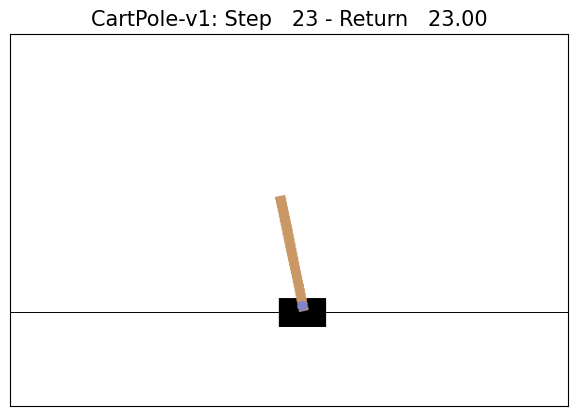

In [33]:
from visualize.visualizer import Visualizer

state_seq, reward_seq = [], []
rng = jax.random.PRNGKey(0)
rng, rng_reset = jax.random.split(rng)

# Instantiate the environment & its settings.
env, env_params = gymnax.make("CartPole-v1")
obs, env_state = env.reset(rng_reset, env_params)
while True:
    state_seq.append(env_state)
    rng, rng_act, rng_step = jax.random.split(rng, 3)
    action = env.action_space(env_params).sample(rng_act)
    next_obs, next_env_state, reward, done, info = env.step(
        rng_step, env_state, action, env_params
    )
    reward_seq.append(reward)
    if done:
        break
    else:
      obs = next_obs
      env_state = next_env_state

cum_rewards = np.cumsum(np.array(reward_seq))
vis = Visualizer(env, env_params, state_seq, cum_rewards)
vis.animate(f"env.gif")

In [18]:
import flax.linen as nn

class Model(nn.Module):
    out_dims: int
    def setup(self):
        # Submodule names are derived by the attributes you assign to. In this
        # case, "dense1" and "dense2". This follows the logic in PyTorch.
        self.dense1 = nn.Dense(64)
        self.dense2 = nn.Dense(64)
        self.out = nn.Dense(self.out_dims)

    def __call__(self,x):
        x = self.dense1(x)
        x = nn.relu(x)
        x = self.dense2(x)
        x = nn.relu(x)
        x = self.out(x)
        return x

In [28]:
import distrax

def generate_session(env, env_params, model, model_params, rng):
    states, actions, rewards =  [], [], []
    rng, rng_reset = jax.random.split(rng)
    # Instantiate the environment & its settings.
    obs, env_state = env.reset(rng_reset, env_params)
    while True:
        states.append(obs)
        rng, rng_act, rng_step = jax.random.split(rng, 3)
        action_logits = model.apply(model_params, obs)
        policy = distrax.Categorical(logits=action_logits)
        action = policy.sample(seed=rng_act)
        actions.append(action)
        next_obs, next_env_state, reward, done, info = env.step(
            rng_step, env_state, action, env_params
        )
        rewards.append(reward)
        if done:
            break
        else:
          obs = next_obs
          env_state = next_env_state

    return states, actions, rewards, rng

In [30]:
rng = jax.random.PRNGKey(0)
rng, rng_reset = jax.random.split(rng)
env, env_params = gymnax.make("CartPole-v1")
model = Model(out_dims=env.action_space().n)
obs, env_state = env.reset(rng_reset, env_params)
rng, model_rng = jax.random.split(rng)
model_params = model.init(model_rng, obs)
states, actions, rewards, rng = generate_session(env, env_params, model, model_params, rng)

In [45]:
np.cumsum(np.array(rewards))[::-1] #Perform a reverse cumulative sum on a (jax) numpy array

Array([11., 10.,  9.,  8.,  7.,  6.,  5.,  4.,  3.,  2.,  1.], dtype=float32)

In [35]:
def loss_fn(model_params, model, states, actions, cumulative_rewards,  action_space_dim):
    logits = model.apply(model_params, states)
    log_probs = nn.log_softmax(logits)
    # select log-probabilities for chosen actions, log pi(a_i|s_i)
    log_probs_for_actions = np.sum(log_probs * nn.one_hot(actions, action_space_dim), axis=1)
    loss = np.mean(cumulative_rewards * log_probs_for_actions)

    return loss


In [43]:
def train_on_session(states, actions, rewards, env, model, model_params, alpha=0.001):
    states = np.array(states)
    actions = np.array(actions)
    rewards = np.array(rewards)
    cumulative_rewards = np.cumsum(np.array(rewards))[::-1]
    action_space_dim = env.action_space().n
    loss_value, grads = jax.value_and_grad(loss_fn,  argnums=0,)(model_params, model, states, actions, cumulative_rewards,  action_space_dim)
    model_params = jax.tree.map(lambda x,y: x + alpha * y, model_params, grads)
    return model_params, loss_value, np.sum(rewards)

In [46]:
train_on_session(states, actions, rewards, env, model, model_params)

({'params': {'dense1': {'bias': Array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  5.59146101e-05,
           -2.50974681e-05,  5.11401631e-05,  1.06340995e-04, -9.56457734e-06,
           -1.00489979e-05,  1.09311877e-04, -1.54836540e-04,  1.28325890e-04,
            9.47660646e-06,  0.00000000e+00,  2.11083225e-05,  8.70882213e-05,
            0.00000000e+00,  3.32853392e-06,  5.17543631e-05,  0.00000000e+00,
            7.91284328e-05,  2.18416426e-05,  3.53647047e-05, -1.23640584e-05,
            2.04832410e-04,  0.00000000e+00,  8.22464244e-06,  8.54570462e-05,
            1.98782553e-04, -4.19566713e-05, -3.30205330e-05, -6.04415982e-05,
            0.00000000e+00, -3.24396169e-05,  0.00000000e+00,  0.00000000e+00,
            1.43824203e-04,  1.02790313e-04,  9.12674514e-05,  3.43116961e-04,
            0.00000000e+00, -1.07082324e-05,  2.86928298e-05, -2.42829392e-05,
            3.11224030e-05,  9.54818279e-06,  8.44290771e-05,  0.00000000e+00,
           -5.93777040e-

In [53]:
loss_values = []
reward_sums = []
for i in range(10**3):
    states, actions, rewards, rng = generate_session(env, env_params, model, model_params, rng)
    model_params, loss_value, reward_sum = train_on_session(states, actions, rewards, env, model, model_params)
    if i % 100 == 0:
        print(f'loss_value={np.mean(loss_value)}, reward_sum={np.mean(reward_sum)}')
        loss_values = []
        reward_sums = []

loss_value=-50.78157043457031, reward_sum=171.0
loss_value=-33.45796203613281, reward_sum=106.0
loss_value=-88.66217041015625, reward_sum=312.0


KeyboardInterrupt: 

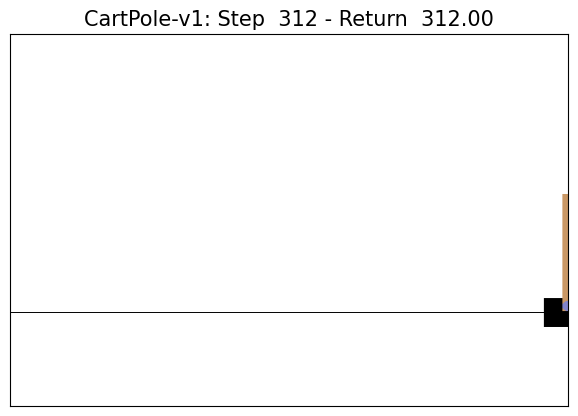

In [63]:
# Instantiate the environment & its settings.
env, env_params = gymnax.make("CartPole-v1")
obs, env_state = env.reset(rng_reset, env_params)
state_seq, reward_seq = [], []
while True:
    state_seq.append(env_state)
    rng, rng_act, rng_step = jax.random.split(rng, 3)
    action_logits = model.apply(model_params, obs)
    action = np.argmax(action_logits)
    next_obs, next_env_state, reward, done, info = env.step(
        rng_step, env_state, action, env_params
    )
    reward_seq.append(reward)
    if done:
        break
    else:
      obs = next_obs
      env_state = next_env_state

cum_rewards = np.cumsum(np.array(reward_seq))
vis = Visualizer(env, env_params, state_seq, cum_rewards)
vis.animate(f"trained_env.gif")